# EdgeAI Assignment – Student Notebook (Starter)

**Course:** Embedded Systems / EdgeAI (UCSC Extension)

**Assignment:** End-to-End EdgeAI Pipeline with OpenMV

## Build a camera-based gesture detector that recognizes LEFT, RIGHT, or NONE and triggers logic on-device — no cloud, no PC at runtime.

---

This notebook guides you through building a complete EdgeAI pipeline using data captured on an OpenMV camera and training/quantizing a small CNN using TensorFlow Lite.

```
PC
 ├─ Data capture
 ├─ Keras training
 ├─ INT8 quantization
 ├─ TFLite export
 ↓
OpenMV
 ├─ TFLite Micro runtime
 ├─ CNN inference
 ├─ Symbolic FSM
 └─ Actuation
```
### Gesture Suggestions
- use left hand and right hand
- use variations for 'none'

![alt text](https://drive.google.com/uc?export=view&id=13Re69BzFl10PgaKo9ewNKT_E8gWpwyPz)

## 1. Data Capture with OpenMV (Manual Step)

Use the OpenMV IDE to capture grayscale 64×64 images.
Run this code inside the OpenVM, which will capture an image twice per second

```python
import sensor, image, time, os

# Configure camera
sensor.reset()
sensor.set_pixformat(sensor.GRAYSCALE)
sensor.set_framesize(sensor.B64X64)
sensor.set_auto_gain(False, gain_db=0)
sensor.set_auto_whitebal(False)
sensor.set_auto_exposure(False, exposure_us=25000)
sensor.skip_frames(time=2000)

# Dataset configuration
LABELS = ["LEFT", "RIGHT", "NONE"]
SAMPLES_PER_LABEL = 75
CAPTURE_INTERVAL_MS = 500
PREVIEW_SECONDS = 15
BASE_PATH = "/flash"

# ----------------------------
# Helper: clear a directory
# ----------------------------
def clear_directory(path):
    try:
        for fname in os.listdir(path):
            os.remove("%s/%s" % (path, fname))
        print("Cleared:", path)
    except OSError:
        print("Could not clear:", path)

# ----------------------------
# Helper: countdown with live
# preview in frame buffer
# ----------------------------
def live_preview_countdown(label, seconds):
    print("\n=============================")
    print("LABEL:", label)
    print("Position yourself now.")
    print("Capturing starts in", seconds, "seconds...")
    print("Watch the frame buffer in OpenMV IDE.")

    start = time.ticks_ms()
    last_printed = seconds

    while True:
        sensor.snapshot()

        elapsed = time.ticks_diff(time.ticks_ms(), start) // 1000
        remaining = seconds - elapsed

        if remaining != last_printed and remaining >= 0:
            print(remaining, "seconds remaining...")
            last_printed = remaining

        if elapsed >= seconds:
            print("GO — starting capture for:", label)
            break

# ----------------------------
# Create/clean directories
# ----------------------------
print("Preparing directories...")
for lbl in LABELS:
    path = "%s/%s" % (BASE_PATH, lbl)
    try:
        os.mkdir(path)
        print("Created:", path)
    except OSError:
        # already exists — clear it out
        clear_directory(path)

# ----------------------------
# Main capture loop
# ----------------------------
for label in LABELS:
    path = "%s/%s" % (BASE_PATH, label)

    live_preview_countdown(label, PREVIEW_SECONDS)

    counter = 0     # always start from 0 after cleanup
    print("CAPTURING", SAMPLES_PER_LABEL, "images for:", label)

    while counter < SAMPLES_PER_LABEL:
        img = sensor.snapshot()
        img = img.copy(x_scale=0.5, y_scale=0.5)   # 64x64 → 32x32
        filename = "%s/%03d.pgm" % (path, counter)
        img.save(filename)
        os.sync()
        counter += 1
        print("Saved:", filename, "(%d/%d)" % (counter, SAMPLES_PER_LABEL))
        time.sleep_ms(CAPTURE_INTERVAL_MS)

    print("Done with label:", label)

os.sync()
print("\n=== ALL LABELS CAPTURED ===")

```

## 2. Upload Dataset to Colab
Download the images, mount the SD card from the camera, download and zip the dataset.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [4]:
import zipfile, os

# auto-detect uploaded zip filename
zip_path = list(uploaded.keys())[0]
print("Unzipping:", zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(".")

# verify structure
print("\nDataset folders found:")
for folder in os.listdir("dataset"):
    count = len(os.listdir(os.path.join("dataset", folder)))
    print(f"  {folder}: {count} images")

from PIL import Image
import os

for label in ["LEFT", "RIGHT", "NONE"]:
    path = "/content/dataset/%s" % label
    sample = os.listdir(path)[0]
    img = Image.open("%s/%s" % (path, sample))
    print("Label: %-10s  Size: %s" % (label, img.size))

Unzipping: dataset.zip

Dataset folders found:
  RIGHT: 300 images
  NONE: 300 images
  LEFT: 300 images
Label: LEFT        Size: (32, 32)
Label: RIGHT       Size: (32, 32)
Label: NONE        Size: (32, 32)


## 3. Dataset Loading and Preprocessing

In [5]:
import numpy as np
from PIL import Image
import os

LABELS = ["LEFT", "RIGHT", "NONE"]
DATASET_PATH = "/content/dataset"

X, y = [], []

for idx, label in enumerate(LABELS):
    path = "%s/%s" % (DATASET_PATH, label)
    for fname in os.listdir(path):
        img = Image.open("%s/%s" % (path, fname)).convert("L")
        img = img.resize((32, 32))
        X.append(np.array(img))
        y.append(idx)

X = np.array(X, dtype=np.float32) / 255.0
X = X.reshape(-1, 32, 32, 1)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:", {label: idx for idx, label in enumerate(LABELS)})

X shape: (900, 32, 32, 1)
y shape: (900,)
Labels: {'LEFT': 0, 'RIGHT': 1, 'NONE': 2}


## 4. Train / Validation Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:  ", len(X_train))
print("Validation samples:", len(X_val))

Training samples:   720
Validation samples: 180


## 5. Model Definition
📌 **How to Construct the Neural Network**

In this assignment, you are not designing a general-purpose neural network.
You are building a very small, efficient classifier that must run on an embedded device with strict memory and compute limits.

Because of these constraints, the network structure is intentionally simple and follows a proven pattern for tiny vision models.

🧠 **What the network needs to do**

Your neural network must:

1. Accept a 64×64 grayscale image
2. Extract simple visual features (edges, motion patterns)
3. Combine those features into a compact representation
4. Output three probabilities:

- NONE
- LEFT
- RIGHT

To do this efficiently, we use a Convolutional Neural Network (CNN).

🧩 **Required building blocks (in order)**

Your model should contain the following components in this order:

---
1️⃣ **Input layer (implicit or explicit)**

- The input to the network is a 64×64 image with one channel.
- In Keras, this is usually specified once at the start:

`layers.Input(shape=(64, 64, 1))`


Why this exists
- Tells the network the shape of incoming data
- Required for model conversion and deployment

2️⃣ **First convolution layer (feature extraction)**

`layers.Conv2D(8, (3, 3), activation="relu")`

What it does
- Slides small 3×3 filters across the image
- Detects simple patterns like:
  - edges
  - corners
  - motion direction hints

Why only 8 filters
- Embedded systems have limited memory
- Fewer filters = fewer parameters = smaller model

3️⃣ **Downsampling (reduce size, increase robustness)**

`layers.MaxPooling2D()`

What it does
- Reduces spatial resolution
- Keeps the strongest features
- Makes the model more tolerant to small shifts

Why this matters
- Reduces computation
- Prevents overfitting
- Essential for embedded performance

4️⃣ **Second convolution layer (higher-level features)**

`layers.Conv2D(16, (3, 3), activation="relu")`

What it does
- Combines simple features into more meaningful ones
- Learns patterns related to motion direction

Why 16 filters
- Slightly more expressive than the first layer
- Still small enough for OpenMV

5️⃣ **Global Average Pooling (critical for embedded)**

`layers.GlobalAveragePooling2D()`

What it does
- Converts feature maps into a single feature vector
- Replaces large fully connected layers

Why this is important
- Dramatically reduces parameter count
- Improves generalization
- Common in production EdgeAI models

⚠️ **This layer is one of the main reasons the model fits on OpenMV.**

6️⃣ **Output layer (classification)**

`layers.Dense(3, activation="softmax")`

What it does
- Produces one probability per class
- Ensures outputs sum to 1.0

Why 3 outputs
- One for each gesture class

🧪 **Putting it all together**

Your final model should conceptually look like this:
```
Input (64×64×1)
 ↓
Conv2D (8 filters)
 ↓
MaxPooling
 ↓
Conv2D (16 filters)
 ↓
GlobalAveragePooling
 ↓
Dense (3 outputs)
```

*This is not arbitrary — it is a standard, well-tested pattern for tiny vision models.*

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Note: input_shape is (32, 32, 1) — not (64, 64, 1) as described in the instructions above.
# Images are captured at 64x64 and downscaled to 32x32 during data capture on the Nicla.

def build_model(input_shape=(32, 32, 1), num_classes=3):
    model = models.Sequential([
        layers.Conv2D(2, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(4, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.GlobalAveragePooling2D(),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_model()
model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 2)      │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 4)      │            76 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 4)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111 (444.00 B)

 Trainable params: 111 (444.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3625 - loss: 1.0892 - val_accuracy: 0.3333 - val_loss: 1.0824
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3333 - loss: 1.0721 - val_accuracy: 0.3333 - val_loss: 1.0577
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4139 - loss: 1.0384 - val_accuracy: 0.4778 - val_loss: 1.0155
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4806 - loss: 0.9913 - val_accuracy: 0.4833 - val_loss: 0.9654
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5847 - loss: 0.9415 - val_accuracy: 0.7889 - val_loss: 0.9143
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6500 - loss: 0.8886 - val_accuracy: 0.6667 - val_loss: 0.8557
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6653 - loss: 0.8369 - val_accuracy: 0.6667 - val_loss: 0.8083
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6667 - loss: 0.7958 - val_accuracy: 0.6667 - val_l

## 6. Training Plots

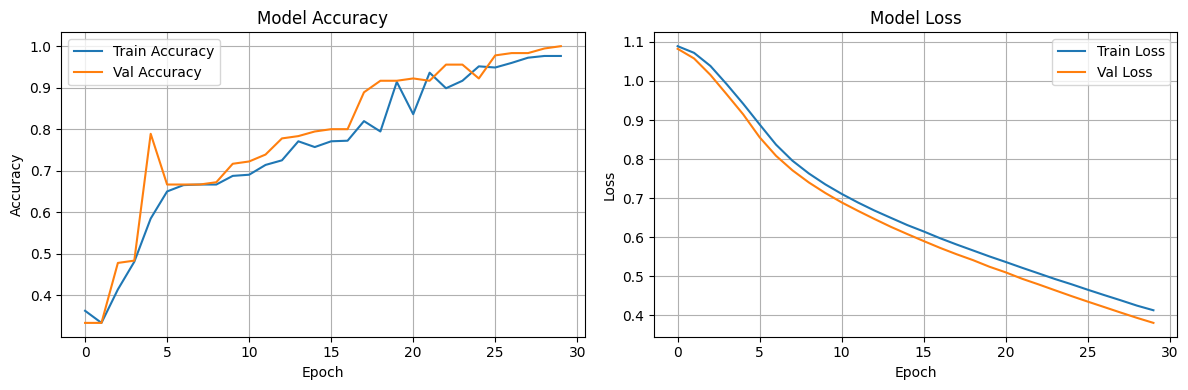

Plot saved as training_history.png


In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()
print("Plot saved as training_history.png")

## 7. Convert to TFLite (Float)


In [9]:

import tensorflow as tf

# Export as SavedModel
model.export('/tmp/gesture_saved_model')

# Float conversion — required for OpenMV v4.8.1 ml module compatibility
converter = tf.lite.TFLiteConverter.from_saved_model('/tmp/gesture_saved_model')
tflite_float = converter.convert()

with open("gesture_float.tflite", "wb") as f:
    f.write(tflite_float)

print("Float model size: %.2f KB" % (len(tflite_float) / 1024))

from google.colab import files
files.download("gesture_float.tflite")

Saved artifact at '/tmp/gesture_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140455920049168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140455920052624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140455920050512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140455920050128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140455920051856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140455920051280: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float model size: 3.44 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Verify Model


In [10]:


import numpy as np

interpreter = tf.lite.Interpreter(model_path="gesture_float.tflite")
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input  dtype:", input_details[0]['dtype'])
print("Input  shape:", input_details[0]['shape'])

correct = 0
for i in range(len(X_val)):
    img = X_val[i:i+1].astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])[0]
    if np.argmax(output) == y_val[i]:
        correct += 1

print("TFLite Validation Accuracy: %.2f%% (%d/%d)" % (correct / len(X_val) * 100, correct, len(X_val)))
print("Keras  Validation Accuracy: %.2f%%" % (model.evaluate(X_val, y_val, verbose=0)[1] * 100))

Input  dtype: <class 'numpy.float32'>
Input  shape: [ 1 32 32  1]
TFLite Validation Accuracy: 100.00% (180/180)
Keras  Validation Accuracy: 100.00%


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 9. Reflection

Answer the following questions:
1. Final model size (KB)?

> 3.5 kb


2. Quantization impact on accuracy?


> Seemingly none, judging by the fact that the TFLite Model and Keras model yield 100% accuracy.

3. Why is this model suitable for OpenMV?


> It's very small, it uses GlobalAveragePooling2D instead of large fully connected layers, it operates on low resolution 32x32 grayscale images, and the inference happens entirely on the microcontroller requiring no internet connection.

4. What would change for a different sensor?


> Our input pipeline would need to change to match the new sensors output format. For example, if the sensor outputs color (RGB) images, the number of input channels would increase from 1 to 3, requiring changes to the input_shape, the dataset preprocessing, and likely the model capacity (more filters). If the resolution differed, the resize() step would need to be updated. The data capture script would also need to be rewritten to use the new sensor's API.




## 10. Self Grading
Run the Python code on your owm implementation and check how the grades are compiled.

In [11]:

"""
Auto-grading / validation script for EdgeAI OpenMV Gesture Assignment
UCSC Extension

Usage:
  python autograde_edgeai.py path/to/student_notebook.ipynb

This script checks:
- Presence of gesture_int8.tflite
- INT8 quantization
- Model size constraint
- Basic inference sanity
"""

import sys
import os
import numpy as np
import tensorflow as tf

MAX_MODEL_SIZE_BYTES = 30000  # 30 KB


def grade_model(tflite_path):
    score = 0
    feedback = []

    if not os.path.exists(tflite_path):
        feedback.append("❌ gesture_int8.tflite not found")
        return score, feedback

    score += 25
    size = os.path.getsize(tflite_path)

    if size <= MAX_MODEL_SIZE_BYTES:
        score += 25
        feedback.append(f"✔ Model size OK ({size} bytes)")
    else:
        feedback.append(f"❌ Model too large ({size} bytes)")

    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    if input_details['dtype'] == np.float32:
      score += 25
      feedback.append("✔ Float32 input confirmed")
    else:
      feedback.append("❌ Model input dtype unexpected: " + str(input_details['dtype']))

    # Sanity inference
    dummy = np.zeros(input_details['shape'], dtype=np.float32)
    interpreter.set_tensor(input_details['index'], dummy)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details['index'])

    if output.shape[-1] == 3:
        score += 25
        feedback.append("✔ Output shape correct (3 classes)")
    else:
        feedback.append("❌ Output shape incorrect")

    return score, feedback


if __name__ == "__main__":
    tflite_path = "gesture_float.tflite"
    score, feedback = grade_model(tflite_path)

    print("Auto-grade score:", score, "/ 100")
    print("Feedback:")
    for f in feedback:
        print(" -", f)


Auto-grade score: 100 / 100
Feedback:
 - ✔ Model size OK (3524 bytes)
 - ✔ Float32 input confirmed
 - ✔ Output shape correct (3 classes)


# Extra Credit
## Use Edge Impulse for the same problem
## Create model and download into your OpenMV cam